# CA2 - Supervised machine learning classification pipeline - applied to pumpkin seed variety classification


### Important information

- Do __not__ use scikit-learn (`sklearn`) or any other high-level machine learning library for this CA
- Explain your code and reasoning in markdown cells or code comments
- Label all graphs and charts if applicable
- If you use code from the internet, make sure to reference it and explain it in your own words
- If you use additional function arguments, make sure to explain them in your own words
- Use the classes `Perceptron`, `Adaline` and `Logistic Regression` from the library `mlxtend` as classifiers (`from mlxtend.classifier import Perceptron, Adaline, LogisticRegression`). _Always_ use the argument `minibatches=1` when instantiating an `Adaline` or `LogisticRegression` object. This makes the model use the gradient descent algorithm for training. Always use the `random_seed=42` argument when instantiating the classifiers. This will make your results reproducible.
- You can use any plotting library you want (e.g. `matplotlib`, `seaborn`, `plotly`, etc.)
- Use explanatory variable names (e.g. `X_train` and `X_train_scaled` for the training data before and after scaling, respectively)
- The dataset is provided in the file `pumpkin_dataset.csv` 

### About the dataset

Each row describes one pumpkin seed, measured automatically from a photograph. The four features are geometric properties of the seed:

- `Compactness`: how close the seed's shape is to a circle (ratio; 1 = perfectly round, smaller = more elongated)
- `Major_Axis_Length`: length of the longest line that fits inside the seed (pixels)
- `Extent`: ratio of the seed area to the area of its bounding box
- `Area`: number of pixels inside the seed

The target `class` is the seed variety: `0` = Çerçevelik, `1` = Ürgüp Sivrisi.

The data comes from Koklu, Sarigil & Ozbek (2021), *The use of machine learning methods in classification of pumpkin seeds (Cucurbita pepo L.)*, Genetic Resources and Crop Evolution 68(7), 2713–2726. https://doi.org/10.1007/s10722-021-01226-0

### Additional clues

- Use the `pandas` library for initial data inspection and preprocessing
- Before training the classifiers, convert the data to raw `numpy` arrays
- For Part IV, you are aiming to create a plot that looks similar to this:
<img src="./example_output_pumpkin.png" width="700">

### Additional information

- Feel free to create additional code or markdown cells if you think it will help you explain your reasoning or structure your code (you don't have to).


## Part I: Data loading and data exploration


### Import necessary libraries/modules:


In [4]:
# Insert your code below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ======================


### Loading and exploring data

1. Load the dataset `pumpkin_dataset.csv` with `pandas`.

2. Check for missing data, report your findings, and remove samples with missing data if any are present.

3. Display the raw data with appropriate plots/outputs and inspect it. Describe the distributions of:
   - feature `"Compactness"`
   - feature `"Area"`
   - the target variable `"class"`

4. Will it be beneficial to scale the data? Why or why not?

It will most probably be beneficial to scale the data since a large difference in scales is observed. Here, the Area feature values range approximately between 50,000–140,000, while Compactness ranges approximately between 0.55–0.9. If we do not scale this data before analysing, features with larger numerical values may dominate the analysis and the features with smaller values might not get equal share in the analysis.

5. Is the data linearly separable using any pairwise combination of features? Based on your observations, can we expect an accuracy close to 100% from a linear classifier?

There seem to be no complete pairwise linear seperation. Therefor we cannot expect an accuracy close to 100% from a linear classifier on this dataset.


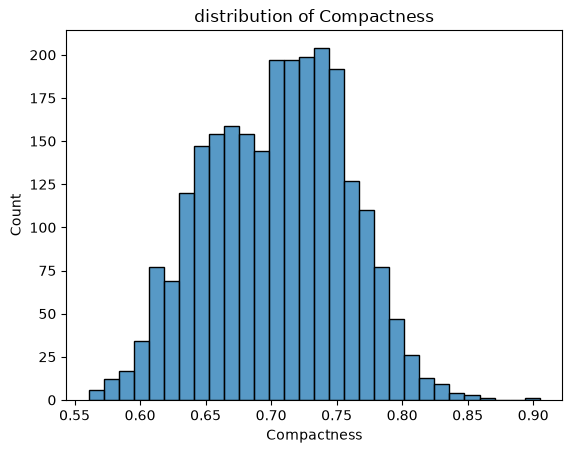

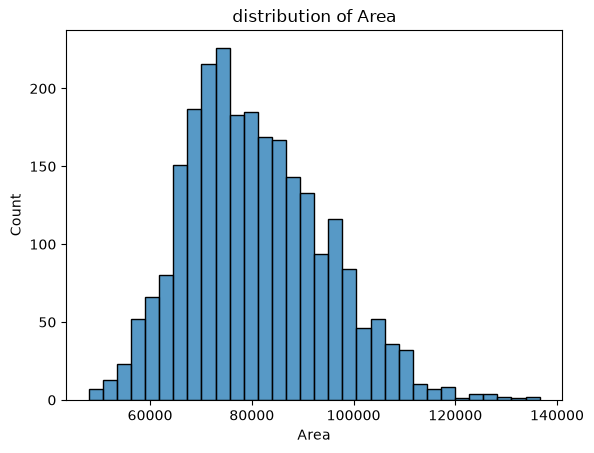

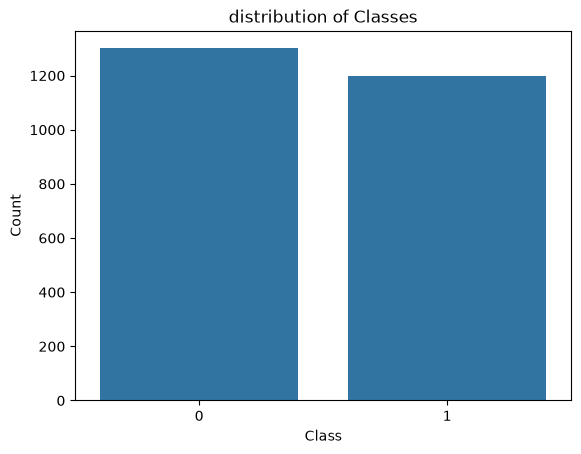

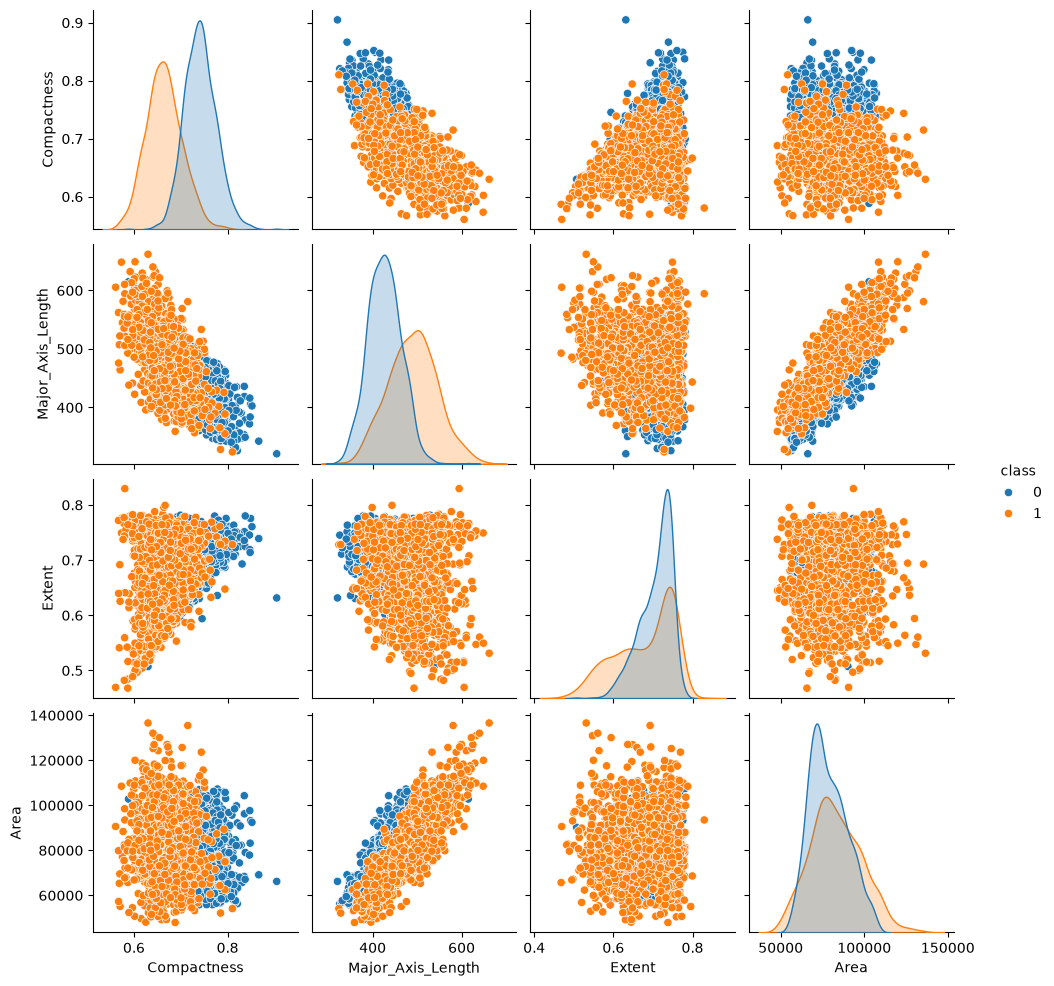

In [ ]:
# Insert your code below

# 1 load data into df 
df = pd.read_csv("pumpkin_dataset.csv")

# 2 : No missing data found #
df.isnull().sum()

# 3 Visualizing 
df[["Compactness", "Area"]].describe()
# Compactness
sns.histplot(data=df, x="Compactness")
plt.xlabel("Compactness")
plt.ylabel("Count")
plt.title("distribution of Compactness")
plt.show()
# Area
sns.histplot(data=df, x="Area")
plt.xlabel("Area")
plt.ylabel("Count")
plt.title("distribution of Area")
plt.show()
# class
sns.countplot(data=df, x="class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("distribution of Classes")
plt.show()

# It will most probably be beneficial to scale the data since a large difference in scales is observed. Here, the Area feature values range approximately between 50,000–140,000, while Compactness ranges approximately between 0.55–0.9. If we do not scale this data before analysing, features with larger numerical values may dominate the analysis and the features with smaller values might not get equal share in the analysis.

# 5 
sns.pairplot(df, hue="class")
plt.show()

# There seem to be no complete pairwise linear seperation. Therefor we cannot expect an accuracy close to 100% from a linear classifier on this dataset.
# ======================

## Part II: Train/Test Split

Divide your dataset into training and testing subsets. Follow these steps to create the split:

1. **Divide the dataset into two data sets, each containing samples of only one class:**
   - Create a DataFrame `df_0` containing all samples with `"class"` equal to `0`.
   - Create a DataFrame `df_1` containing all samples with `"class"` equal to `1`.

2. **Split into training and test sets by randomly sampling entries from the data frames:**
   - Create a DataFrame `df_0_train` by sampling `75%` of the entries from `df_0` (use the `sample` method with `random_state=42`).
   - Create a DataFrame `df_1_train` using the same approach with `df_1`.
   - Create a DataFrame `df_0_test` containing the remaining entries of `df_0` (use `df_0.drop(df_0_train.index)`).
   - Create a DataFrame `df_1_test` using the same approach with `df_1`.

3. **Merge the datasets split by classes back together:**
   - Create a DataFrame `df_train` containing all entries from `df_0_train` and `df_1_train` (use the `concat` method).
   - Create a DataFrame `df_test` containing all entries from the two test sets.

4. **Create the following data frames from these splits:**
   - `X_train`: contains all columns of `df_train` except for the target feature `"class"`
   - `X_test`: contains all columns of `df_test` except for the target feature `"class"`
   - `y_train`: contains only the target feature `"class"` for all samples in the training set
   - `y_test`: contains only the target feature `"class"` for all samples in the test set


5. **Check that your sets have the expected sizes/shape by printing the number of rows and columns (`shape`) of the data sets.**
   - (Sanity check: there should be **4 features**, and the training set should contain roughly **75%** of the total samples, with the test set containing the remaining **25%**.)

Since 75% of 2500 = 1875 and 25% of 2500 = 625, the sanity check works perfectly with the reults: 
X_train shape: (1875, 4)
X_test shape: (625, 4)
y_train shape: (1875,)
y_test shape: (625,)


6. **Explain the purpose of this slightly complicated procedure.**
   - Why did we first split into the two classes?
   - Why did we then split into a training and a testing set?

Because here the porportions of clas 0 and 1 in the origianl data are not 50/50. Therefore, if we instead had randomely splited the data into 75% training and 25% test, the class porportions that would be (randomely) selected could differ due to the random sampling. With this method, this is no more the case and as we see in the next section (7), the porpurtions of samples with class 0 are always the same with this method in original, training, and test dataset. 

We set a part (25%) of the data aside for the testing beuace we need to use that after initial training in order to see how the modle performs in face of unseen data and also calculate the error for evaluating the model. 

7. **What is the share (in percent) of samples with class `0` in the test set, training set, and in the initial data set?**

as explained in q6, the share in all the three sets is the same = 52% = the preserved shares from the initial dataset.


In [ ]:
# Insert your code below
# 1 
df_0 = df[df["class"] == 0]
df_1 = df[df["class"] == 1]

#2 
df_0_train = df_0.sample(frac=0.75, random_state=42)
df_1_train = df_1.sample(frac=0.75, random_state=42)

df_0_test = df_0.drop(df_0_train.index)
df_1_test = df_1.drop(df_1_train.index)

#3 
df_train = pd.concat([df_0_train, df_1_train])
df_test = pd.concat([df_0_test, df_1_test])

#4 
X_train = df_train.drop(columns=["class"])
X_test = df_test.drop(columns=["class"])

y_train = df_train["class"]
y_test = df_test["class"]

# 5 Checking the dimentions 
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Since 75% of 2500 = 1875 and 25% of 2500 = 625, the sanity check works perfectly with the reults: 
# X_train shape: (1875, 4)
# X_test shape: (625, 4)
# y_train shape: (1875,)
# y_test shape: (625,)

# 6 the % of samples in class 0 
class_0_train = (y_train == 0).mean() * 100
class_0_test = (y_test == 0).mean() * 100
class_0_initial = (df["class"] == 0).mean() * 100

print("Class 0 training set:", class_0_train, "%")
print("Class 0 test set:", class_0_test, "%")
print("Class 0 initial dataset:", class_0_initial, "%")

# Because here the porportions of clas 0 and 1 in the origianl data are not 50/50. Therefore, if we instead had randomely splited the data into 75% training and 25% test, the class porportions that would be (randomely) selected could differ due to the random sampling. With this method, this is no more the case and as we see in the next section (7), the porpurtions of samples with class 0 are always the same with this method in original, training, and test dataset. 
# We set a part (25%) of the data aside for the testing beuace we need to use that after initial training in order to see how the modle performs in face of unseen data and also calculate the error for evaluating the model. 

# 7 
# as explained in q6, the share in all the three sets is the same = 52% = the preserved shares from the initial dataset.
# ======================


X_train shape: (1875, 4)
X_test shape: (625, 4)
y_train shape: (1875,)
y_test shape: (625,)
Class 0 training set: 52.0 %
Class 0 test set: 52.0 %
Class 0 initial dataset: 52.0 %


### Convert data to numpy arrays and shuffle the training data

Many machine learning models (including those you will use later in this assignment) do not accept `pandas` DataFrames as input. Instead, they require the data to be provided as raw `numpy` arrays.  
In this step, convert the DataFrames `X_train`, `X_test`, `y_train`, and `y_test` into the corresponding numpy arrays with the same variable names.

In addition, shuffle the training data. This is necessary because the training set is currently ordered by class (all samples of class 0 followed by all samples of class 1).  
In Part IV, the classifiers will be trained using the **first _n_ samples** of the training set. If the data were not shuffled, the models would initially be trained only on samples from a single class, which would lead to biased learning and unreliable performance.

Nothing to be done here, just execute the cell.


In [16]:
# convert to numpy arrays
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

# shuffle training data
np.random.seed(42) # for reproducibility
shuffle_index = np.random.permutation(len(X_train)) # generate random indices
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index] # shuffle data by applying reordering with the random indices

## Part III: Scaling the data

1. Standardize the training _and_ test data so that each feature has a mean of 0 and a standard deviation of 1.
2. Check that the scaling was successful
   - by printing the mean and standard deviation of each feature in the scaled training set
   - by putting the scaled training set into a DataFrame and making a violin plot of the data

__Hint:__ use the `axis` argument to calculate mean and standard deviation column-wise.

__Important:__ Avoid data leakage!  
Compute the mean and standard deviation only on the training data, and then apply the same transformation to both the training and test sets.

__More hints:__

1. For each column, subtract the training mean $(\mu_{\text{train}})$ from each value in that column  
2. Divide the result by the training standard deviation $(\sigma_{\text{train}})$

Mathematically, this transformation for each column is:

$$ X_{\text{scaled}} = \frac{X - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

where:
- $X_{\text{scaled}}$ are the transformed column values (a column vector)  
- $X$ is the original column  
- $\mu_{\text{train}}$ is the mean of the column computed on the training set  
- $\sigma_{\text{train}}$ is the standard deviation of the column computed on the training set  


Mean: [ 1.63539589e-14 -8.46582064e-16 -1.05821130e-14  1.49332398e-16]
Standard deviation: [1. 1. 1. 1.]


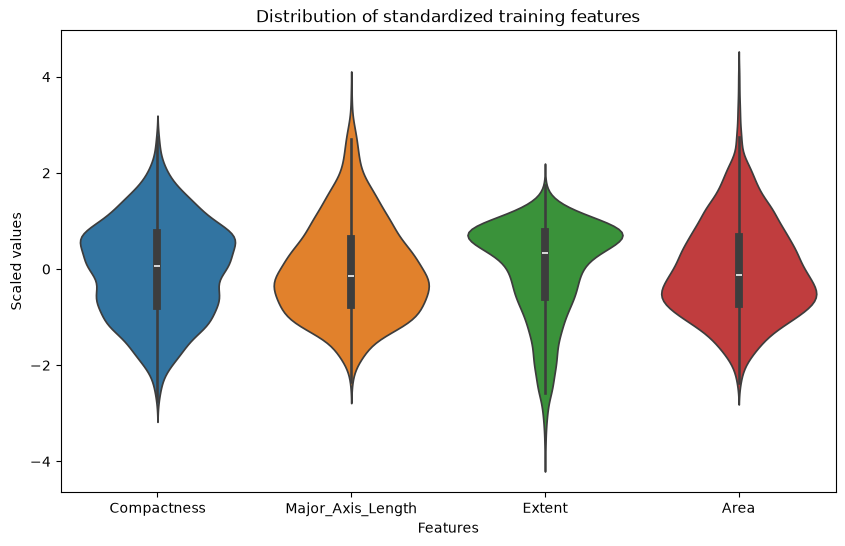

In [ ]:
# Insert your code below
# 1 
# Calculating the mean and standard deviation of each feature using parameters from training data only
X_train_mean = np.mean(X_train, axis=0)
X_train_std = np.std(X_train, axis=0)
# Standardizing both train and test data by deducting the mean and deviding by std 
X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

# 2 the mean and std of each feature (must be 0 and 1, recpectively)
print("Mean:", np.mean(X_train_scaled, axis=0))
print("Standard deviation:", np.std(X_train_scaled, axis=0))

# making scaled training data dataframe 
feature_names = ["Compactness", "Major_Axis_Length", "Extent", "Area"]
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)

# violine plot visualization 
plt.figure(figsize=(10, 6))
sns.violinplot(data=X_train_scaled_df)
plt.xlabel("Features")
plt.ylabel("Scaled values")
plt.title("Distribution of standardized training features")
plt.show()

# the results show 1 for all standard deviations and very small, close to 0 values for the means which fits whit the standardization purpose. 
# ======================


## Part IV: Training and evaluation with different dataset sizes and training times

Often, a larger dataset size will yield better model performance. (As we will learn later, this usually prevents overfitting and increases the generalization capability of the trained model.)
However, collecting data is usually rather expensive.

In this part of the exercise, you will investigate

- how the model performance changes with varying dataset size
- how the model performance changes with varying numbers of epochs/iterations of the optimizer/solver (increasing training time).

For this task (Part IV), use the `Adaline`, `Perceptron`, and `LogisticRegression` classifiers from the `mlxtend` library. All use the gradient descent (GD) algorithm for training.

__Important__: Use a learning rate of `1e-5` (`0.00001`) for all classifiers, and use the argument `minibatches=1` when initializing the `Adaline` and `LogisticRegression` classifiers (this will make sure they use GD). For all three classifiers, pass `random_seed=42` when initializing the classifier to ensure reproducibility of the results.

### Model training

Train the models using progressively larger subsets of your dataset, specifically: first 50 rows, first 100 rows, first 150 rows, ..., first 650 rows, first 700 rows (in total $14$ different variants).

For each number of rows train the model with progressively larger number of epochs: 2, 7, 12, 17, ..., 87, 92, 97 (in total $20$ different model variants).

This will result in $14 \times 20 = 280$ models obtained from the different combinations of subsets and number of epochs. An output of the training process could look like this:

```
Model (1) Train a model with first 50 rows of data for 2 epochs
Model (2) Train a model with first 50 rows of data for 7 epochs
Model (3) Train a model with first 50 rows of data for 12 epochs
...
Model (21) Train a model with first 100 rows of data for 2 epochs
Model (22) Train a model with first 100 rows of data for 7 epochs
...
Model (279) Train a model with first 700 rows of data for 92 epochs
Model (280) Train a model with first 700 rows of data for 97 epochs
```

### Model evaluation

For each of the $280$ models, calculate the __accuracy on the test set__ (do __not__ use the score method but compute accuracy yourself).
Store the results in the provided 2D numpy array (it has $14$ rows and $20$ columns).
The rows of the array correspond to the different dataset sizes, and the columns correspond to the different numbers of epochs.

### Tasks
1. Train the $280$ Adaline classifiers as mentioned above and calculate the accuracy for each of the $280$ variants.
2. Generalize your code so that it is doing the same procedure for all three classifiers: `Perceptron`, `Adaline`, and `LogisticRegression` after each other. Store the result for all classifiers. You can for example use an array of shape $3\times14\times20$ to store the accuracies of the three classifiers.

Note that executing the cells will take some time (but on most systems it should not be more than 5 minutes).


In [ ]:
# Train and evaluate all model variants
# Insert your code below

## Task 1 - Adaline ## 

# setting the 14 data row varients 50-700 in steps of 50
dataset_sizes = np.arange(50, 701, 50)
# setting the 20 epochs column varients 2-97 in steps of 5
epochs = np.arange(2, 98, 5)
# used np.arange(start, stop, step) here for implementing them
print(dataset_sizes)
print(epochs)
# results: 
# [ 50 100 150 200 250 300 350 400 450 500 550 600 650 700]
# [ 2  7 12 17 22 27 32 37 42 47 52 57 62 67 72 77 82 87 92 97]

# creating a 14 × 20 array (that will eventually store the results): 
adaline_accuracies = np.zeros((14, 20))

# Adeline model with 50 samples 2 epochs:
# subsetting first 50 rows of training data using [:50] so it dosnt include row index 50 (since indexing starts at 0, first 50 samples = 0-49)
X_train_subset = X_train_scaled[:50]
y_train_subset = y_train[:50]

# creating adeline, setting learning rate eta=1e-5, minibatches=1 to make sure gradian decent is used, random_seed=42 
adaline_model = Adaline(eta=1e-5, epochs=2, minibatches=1, random_seed=42)

# training the adeline model (on training data)
adaline_model.fit(X_train_subset, y_train_subset)

# using the train data to predict classess of unseet (test) data
y_pred = adaline_model.predict(X_test_scaled)

# calculating accuracy = proportion of correct predicticted lables (withouth score method)
accuracy = np.mean(y_pred == y_test)

# storing the results in the previously made adaline_accuracies array's first cell
adaline_accuracies[0, 0] = accuracy

# results
print("Accuracy:", accuracy)

## Training 280 adeline model for 14 size combinations as well is 20 epochs now | using nested-loop approach can be appropriate here instead of manually ##

# creating another 14 × 20 array for the 280 model results
adaline_accuracies_280 = np.zeros((14, 20))

# loop 
for row_index_280, dataset_size_280 in enumerate(dataset_sizes):
    for column_index_280, n_epochs_280 in enumerate(epochs):

        X_train_subset_280 = X_train_scaled[:dataset_size_280]
        y_train_subset_280 = y_train[:dataset_size_280]

        # create a new adaline model 280
        adaline_model_280 = Adaline(eta=1e-5, epochs=n_epochs_280, minibatches=1, random_seed=42)

        # training the 280 model 
        adaline_model_280.fit(X_train_subset_280, y_train_subset_280)

        # predict classes of unseen (test) data
        y_pred_280 = adaline_model_280.predict(X_test_scaled)

        # accuracy 
        accuracy_280 = np.mean(y_pred_280 == y_test)

        # store the accuracy in the adaline_accuracies_280 array 
        adaline_accuracies_280[row_index_280, column_index_280] = accuracy_280

# adeline 280 results 
print("Adaline accuracies", adaline_accuracies_280)


## Task 2 - Generalize for all three classifiers: `Perceptron`, `Adaline`(already done above) , and `LogisticRegression` ## 

## Perceptron ## 

# creating a 14 × 20 array (that will eventually store the results): 
perceptron_accuracies_280 = np.zeros((14, 20))

# loop 
for row_index_280, dataset_size_280 in enumerate(dataset_sizes):
    for column_index_280, n_epochs_280 in enumerate(epochs):

        # training samples 
        X_train_subset_280 = X_train_scaled[:dataset_size_280]
        y_train_subset_280 = y_train[:dataset_size_280]

        # create new Perceptron model
        perceptron_model_280 = Perceptron(eta=1e-5, epochs=n_epochs_280, random_seed=42)

        # train 
        perceptron_model_280.fit(X_train_subset_280, y_train_subset_280)

        # predict classes of unseen (test( data
        y_pred_280 = perceptron_model_280.predict(X_test_scaled)

        # accuracy
        accuracy_280 = np.mean(y_pred_280 == y_test)

        # store accuracy
        perceptron_accuracies_280[row_index_280, column_index_280] = accuracy_280

# Perceptron 280 results
print("perceptron accuracies", perceptron_accuracies_280)

## LogisticRegression ##

# creating a 14 × 20 array (that will eventually store the results): 
logistic_accuracies_280 = np.zeros((14, 20))

# loop
for row_index_280, dataset_size_280 in enumerate(dataset_sizes):
    for column_index_280, n_epochs_280 in enumerate(epochs):

        # training 
        X_train_subset_280 = X_train_scaled[:dataset_size_280]
        y_train_subset_280 = y_train[:dataset_size_280]

        # create a Logistic Regression model with minibatches=1 
        logistic_model_280 = LogisticRegression(eta=1e-5, epochs=n_epochs_280, minibatches=1, random_seed=42)

        # train 
        logistic_model_280.fit(X_train_subset_280, y_train_subset_280)

        # predict classes of unseen (test) data (a sigmoid output equal or higher than 0.5 = class 1) 
        y_pred_280 = logistic_model_280.predict(X_test_scaled)

        # accuracy
        accuracy_280 = np.mean(y_pred_280 == y_test)

        # store accuracy
        logistic_accuracies_280[row_index_280, column_index_280] = accuracy_280

# Results 
print("logistic accuracies", logistic_accuracies_280)

# So now we have it for all the three classification models in 14 × 20 arrays: 
# adaline_accuracies_280 
# perceptron_accuracies_280 
# logistic_accuracies_280 

# running time is around 4 minutes

# ======================


[ 50 100 150 200 250 300 350 400 450 500 550 600 650 700]
[ 2  7 12 17 22 27 32 37 42 47 52 57 62 67 72 77 82 87 92 97]
Accuracy: 0.4448
Adaline accuracy [[0.4448 0.496  0.5328 0.5648 0.608  0.6192 0.648  0.6704 0.6848 0.6928
  0.7168 0.728  0.7344 0.7456 0.744  0.7536 0.7568 0.7648 0.7728 0.7744]
 [0.464  0.5472 0.616  0.6736 0.704  0.7424 0.76   0.7664 0.7776 0.7888
  0.792  0.7936 0.7936 0.7936 0.7952 0.7968 0.7936 0.7936 0.7968 0.8   ]
 [0.4864 0.6048 0.6928 0.7376 0.7808 0.7824 0.7888 0.7952 0.7984 0.8096
  0.816  0.8208 0.824  0.8224 0.8224 0.824  0.8256 0.8256 0.8272 0.8272]
 [0.5088 0.6416 0.7312 0.7808 0.7904 0.7984 0.8176 0.824  0.8256 0.824
  0.8208 0.8192 0.8224 0.8256 0.8224 0.824  0.8272 0.8272 0.8272 0.8304]
 [0.528  0.6928 0.7776 0.7952 0.8128 0.824  0.8256 0.824  0.824  0.8224
  0.8272 0.8288 0.824  0.8288 0.8288 0.8336 0.8336 0.8352 0.8384 0.84  ]
 [0.5392 0.7152 0.7856 0.8016 0.8144 0.824  0.8288 0.8272 0.8304 0.8304
  0.832  0.832  0.8304 0.8336 0.832  0.8304 0.832 

### Performance visualization

Plot the performance measure for all classifiers (accuracy on the test set; use the result array from above) of all the $280$ variants for each classifier in a total of three heatmaps using, for example `seaborn` or `matplotlib` directly.

The color should represent the accuracy on the test set, and the x and y axes should represent the number of epochs and the dataset size, respectively.
Which one is x and which one is y is up to you to decide. Look in the example output at the top of the assignment for inspiration for how the plot could look like and how it could be labeled nicely. (But use the correct numbers corresponding to your dataset sizes and number of epochs.)


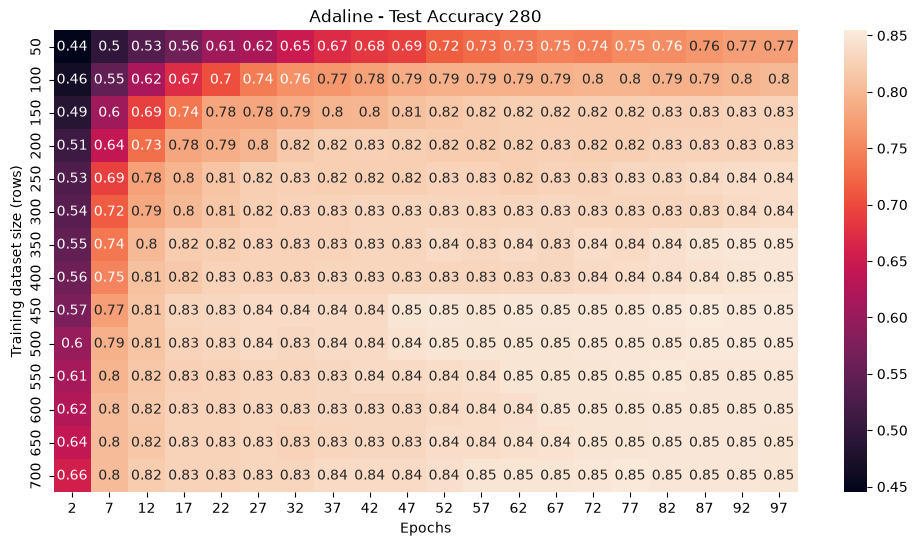

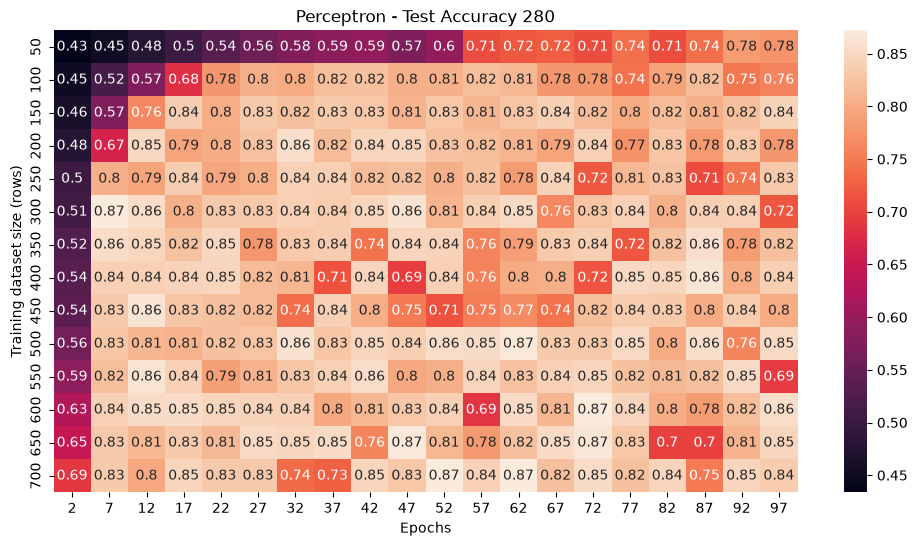

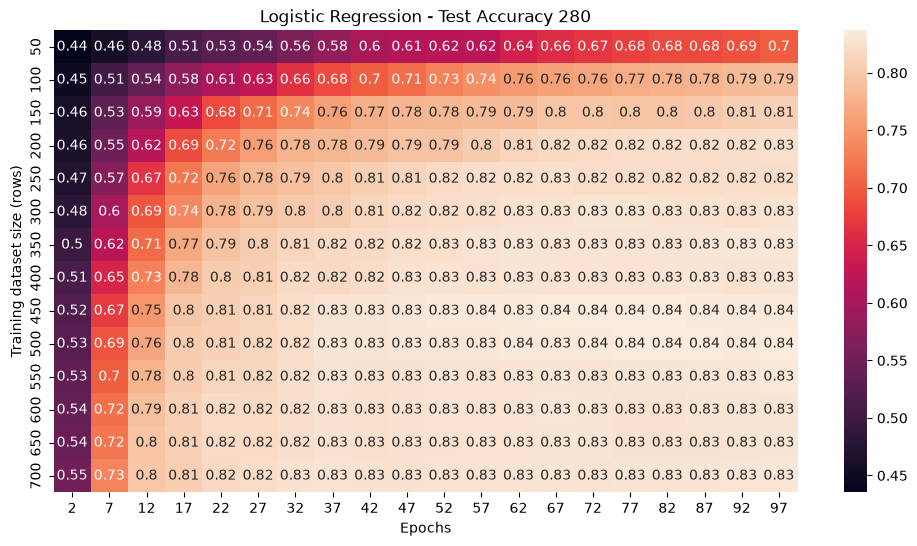

In [ ]:
# Insert your code below

## Heatmap for Adaline ##

# creating the figure and plotting area
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

# creating heatmap from the adaline_accuracies_280 results, we also added set annot=True compared to example output to display the accuracy values as well
sns.heatmap(adaline_accuracies_280, ax=axes, xticklabels=epochs, yticklabels=dataset_sizes, annot=True)

# labeling the axes x for epochs and y for size and title for the whole plot
axes.set_xlabel("Epochs")
axes.set_ylabel("Training dataset size (rows)")
axes.set_title("Adaline - Test Accuracy 280")

# display Heatmap
plt.show()

## Heatmap for Perceptron ##
# following the same code as Adaline
fig, axes = plt.subplots(1, 1, figsize=(12, 6))
sns.heatmap(perceptron_accuracies_280, ax=axes, xticklabels=epochs, yticklabels=dataset_sizes, annot=True)
axes.set_xlabel("Epochs")
axes.set_ylabel("Training dataset size (rows)")
axes.set_title("Perceptron - Test Accuracy 280")
plt.show()


## Heatmap for Logistic Regression ##
fig, axes = plt.subplots(1, 1, figsize=(12, 6))
sns.heatmap(logistic_accuracies_280, ax=axes, xticklabels=epochs, yticklabels=dataset_sizes, annot=True)
axes.set_xlabel("Epochs")
axes.set_ylabel("Training dataset size (rows)")
axes.set_title("Logistic Regression - Test Accuracy 280")
plt.show()

# ======================


# Part V: Some more plotting
For the following cell to execute you need to have the variables `X_train_scaled` and `y_train` (to train the model) as well as `X_test_scaled` and `y_test` (to plot the test samples).
Complete at least up until Part III. Executing the cell will plot something.

This dataset has 4 features, so the plot will be a 4×4 grid showing pairwise feature decision regions.


1. Add code comments explaining what the lines are doing

2. What is the purpose of the plot?

The purpose is visualisign the trained logistic regression calssifier's pairwise combinations of features. Si 4 features in the dataset so we need a combination of 4 × 4 = 16 2D plots to visualize all of the pairs and see how the model has done the classification and predicted class 0 or 1 and chosen the decision boundry. 


3. Describe all components of the subplot and then comment in general on the entire plot. What does it show? What does it not show?

Each subplot represents one pairwise combination of the 4 features including compactness (0), Major_Axis_Length (1), Extent (2), and Area (3). 
The background color (yellow-blue) represents the predicted probability of class 1 produced by the model at artificial positions. 
The black line represents the decision boundry (when p(class 1) = 0.5)) which is linear in logistic regression 
The plotted points represtnt the test samples, blue traingle = class 0, yellow circle = class 1 
The plots shows how the model separates the classes for different feature combinations and how well the test samples align with the predicted decision regions (on the sides of decision boundry)
In the axes we have the features paired against each other in 2d, but the plots do not show all the features simultaniously as it would need a 4d plot. Each plot only represent a slice where two features are varying and the remaining features are fixed at zero (standardized mean). So it cannot alone show for all the model's performance or accuracy. 




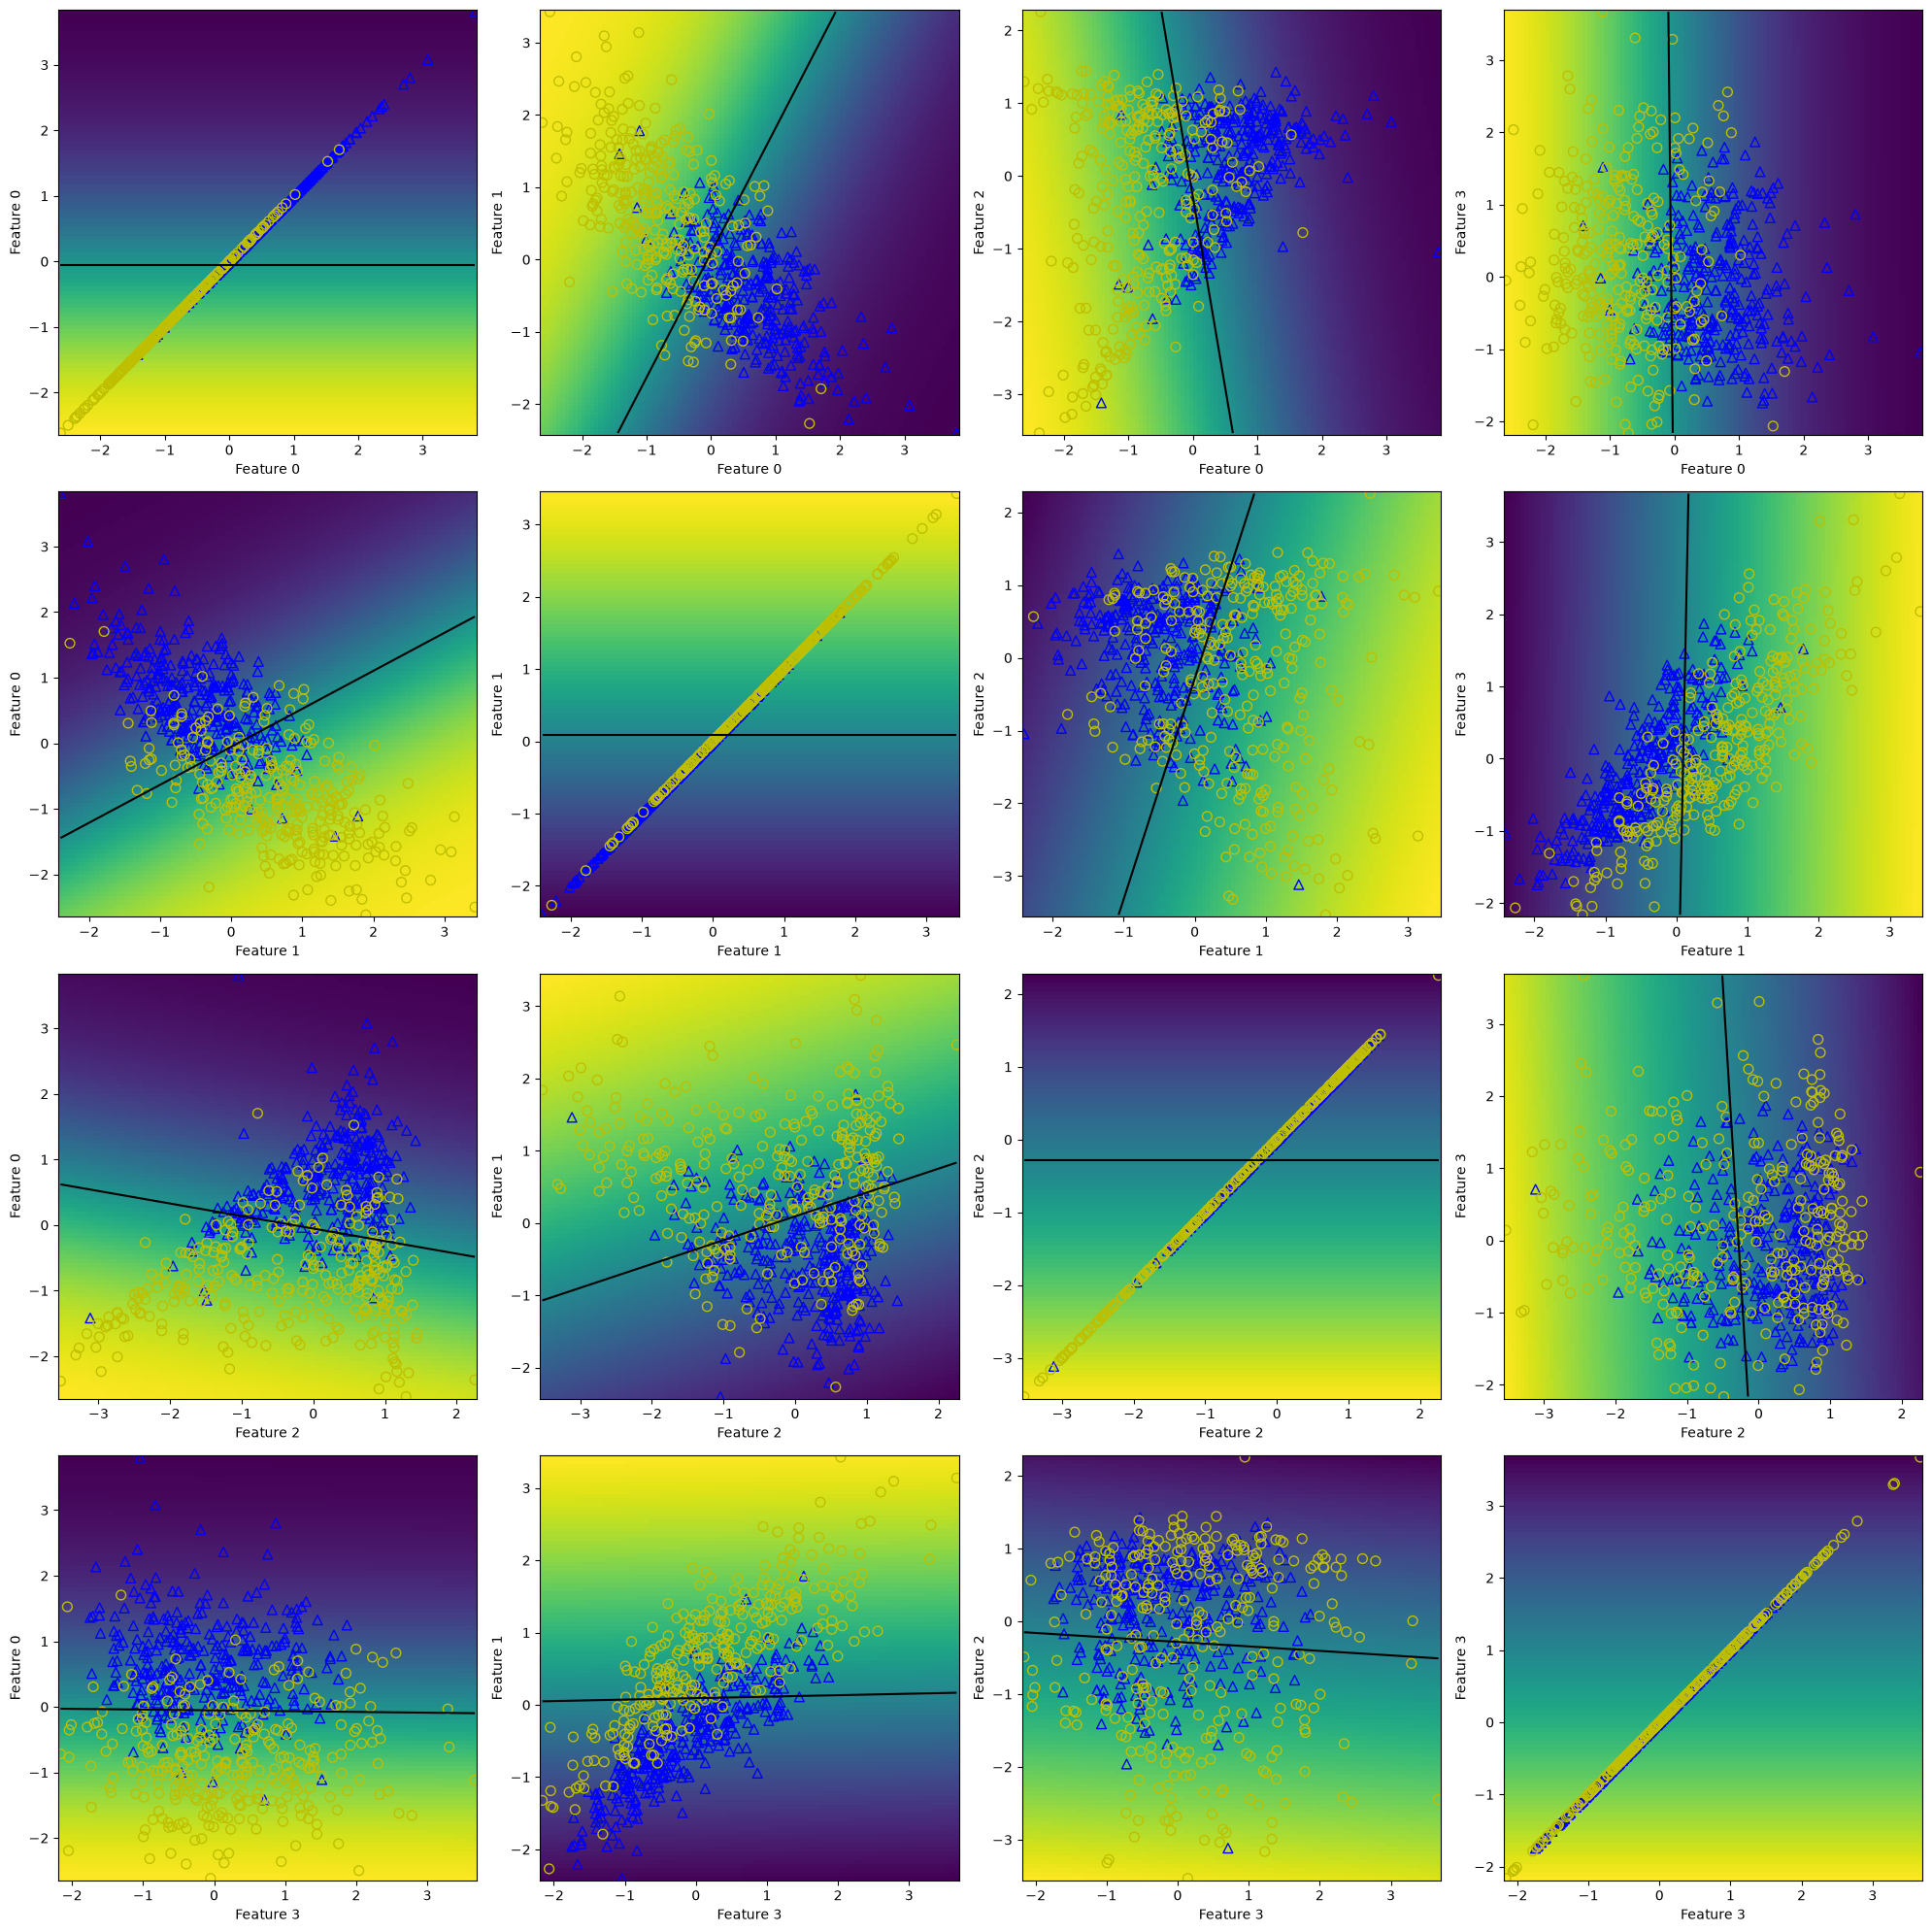

In [ ]:
# chooses the number of features automatically from the data
n_features = X_test_scaled.shape[1]

# n_features rows × n_features columns #  figsize controles the plot size in inches (for later readability of the plot) 
fig, axes = plt.subplots(n_features, n_features, figsize=(5*n_features, 5*n_features))

# finding min and max values of each feature in test data to determine plotting range covered by test data X_test_scaled. axis=0 operates it for each column/feature separatly. 
mins = X_test_scaled.min(axis=0)
maxs = X_test_scaled.max(axis=0)

# this loop, takes the values in the range; here 4, and for our 4 features, will create the 4 × 4 = 16 feature combinations for i and j 
for i in range(n_features):
    for j in range(n_features):
        # i is stores as feature_1 and j as feature_2 which together would determine what pair of features are plotted
        # the 4 features here which will include compactness (0), Major_Axis_Length (1), Extent (2), Area (3)
        feature_1 = i
        feature_2 = j
        ax = axes[i, j]

        # sets the label for the x and y axes as the index in feature_1 and feature_2
        ax.set_xlabel(f"Feature {feature_1}")
        ax.set_ylabel(f"Feature {feature_2}")

        # Create grid for the two selected features
        # starts at the minimum and finishes at the maximum and creates 100 positions in btween (creates ariticial grid)
        x0 = np.linspace(mins[feature_1], maxs[feature_1], 100)
        x1 = np.linspace(mins[feature_2], maxs[feature_2], 100)

        # combines the grid into 100 × 100 = 10000 coordiante positions with every possible combination, x0 feature_1 containing and x1 containing feature_2 as set before 
        X0, X1 = np.meshgrid(x0, x1)

        # Create full feature matrix with other features set to 0
        # x0.size = 100 × 100 = 10000 # n_features = 4 # X_plot = (10000, 4)
        # the two selected features vary, while the remaining features stay = 0 since the data was standardized np.zeros
        # ravel() flattens the 2d 100 × 100 = 10000 grid to 1d with 10000 values and puts it as column in X_plot and then dose the same for the second feature 
        X_plot = np.zeros((X0.size, n_features))
        X_plot[:, feature_1] = X0.ravel()
        X_plot[:, feature_2] = X1.ravel()

        # Predict probability of class 1
        # predict_proba() has continuous probability output; it being closer to either 0 or 1 indicating stronger support for that class (in contrast to clf.predict() which gave final class labels (0 or 1))
        # y_pred is still flatten 10000 grid, reshape(X0.shape) turns it back to the 100×100 2d format
        y_pred = clf.predict_proba(X_plot)
        Z = y_pred.reshape(X0.shape)

        # Plot probability surface
        # the color at ax.pcolor shows predicted class-1 probabilities at the artificail locations 
        ax.pcolor(X0, X1, Z, shading="auto")

        # Plot decision boundary (p = 0.5) # 0.5 is the treshhold (decision boundary) between class 0 and 1
        # colors="k" = black 
        ax.contour(X0, X1, Z, levels=[0.5], colors="k")

        # Plot test samples
        # y_test == 0 creates a boolean selectio, if real class = 0 = true, if not = false 
        # color="b" = blue, marker="^" = triangle for class 0 and facecolors="none" = not filling it insode # s=50 marker size for the visualizing points # 
        # color="y" = yellow, marker="o" = circles 
        ax.scatter(
            X_test_scaled[y_test == 0, feature_1],
            X_test_scaled[y_test == 0, feature_2],
            color="b", marker="^", s=50, facecolors="none"
        )

        ax.scatter(
            X_test_scaled[y_test == 1, feature_1],
            X_test_scaled[y_test == 1, feature_2],
            color="y", marker="o", s=50, facecolors="none"
        )# it creates "one" Logistic Regression classifier and trains it using "all" of the scaled training data (X_train_scaled) with samples and labels 
# learning rate = eta=1e-5 (the constant that controls the size of each rate update in Gradiant Decent; whith larger eta leading to larger steps)
# epochs=300 (training process is done for 300 epochs; each epoch is a pass over the training dataset and updating the wights of the model accordingly)
# minibatches=1 (one batch containing the training data; batch Gradiant Dicent)
# random_seed=42 
clf = LogisticRegression(eta=1e-5, epochs=300, minibatches=1, random_seed=42)
clf.fit(X_train_scaled, y_train)


# adhusting spaing between subplots 
fig.tight_layout()
# display the 4 × 4 plot 
plt.show()

## Part VI: Additional discussion

### Part I:
1. What kind of plots did you use to visualize the raw data, and why did you choose these types of plots?

### Part II:
1. What happens if we don't shuffle the training data before training the classifiers like in Part IV?
2. How could you do the same train/test split (Point 1.-4.) using scikit-learn?

### Part IV:
1. How does increasing the dataset size affect the performance of the logistic regression model? Provide a summary of your findings.
2. Describe the relationship between the number of epochs and the model accuracy.
3. Which classifier is much slower to train and why do you think that is?
4. One classifier shows strong fluctuations in accuracy for different dataset sizes and number of epochs. Which one is it and why do you think this happens?
